1m: 使用列 'PositionError_m' 作为误差数据
1m: 读取了 10 个有效误差数据
1.5m: 使用列 'PositionError_m' 作为误差数据
1.5m: 读取了 10 个有效误差数据
2m: 使用列 'PositionError_m' 作为误差数据
2m: 读取了 10 个有效误差数据
2.5m: 使用列 'PositionError_m' 作为误差数据
2.5m: 读取了 10 个有效误差数据

数据统计信息:
------------------------------------------------------------
1m:
  样本数量: 10
  均值: 0.267 m
  中位数: 0.239 m
  最小值: 0.048 m
  最大值: 0.526 m
  标准差: 0.136 m

1.5m:
  样本数量: 10
  均值: 0.812 m
  中位数: 0.858 m
  最小值: 0.405 m
  最大值: 1.111 m
  标准差: 0.209 m

2m:
  样本数量: 10
  均值: 0.161 m
  中位数: 0.084 m
  最小值: 0.008 m
  最大值: 0.575 m
  标准差: 0.170 m

2.5m:
  样本数量: 10
  均值: 0.497 m
  中位数: 0.456 m
  最小值: 0.236 m
  最大值: 0.839 m
  标准差: 0.208 m



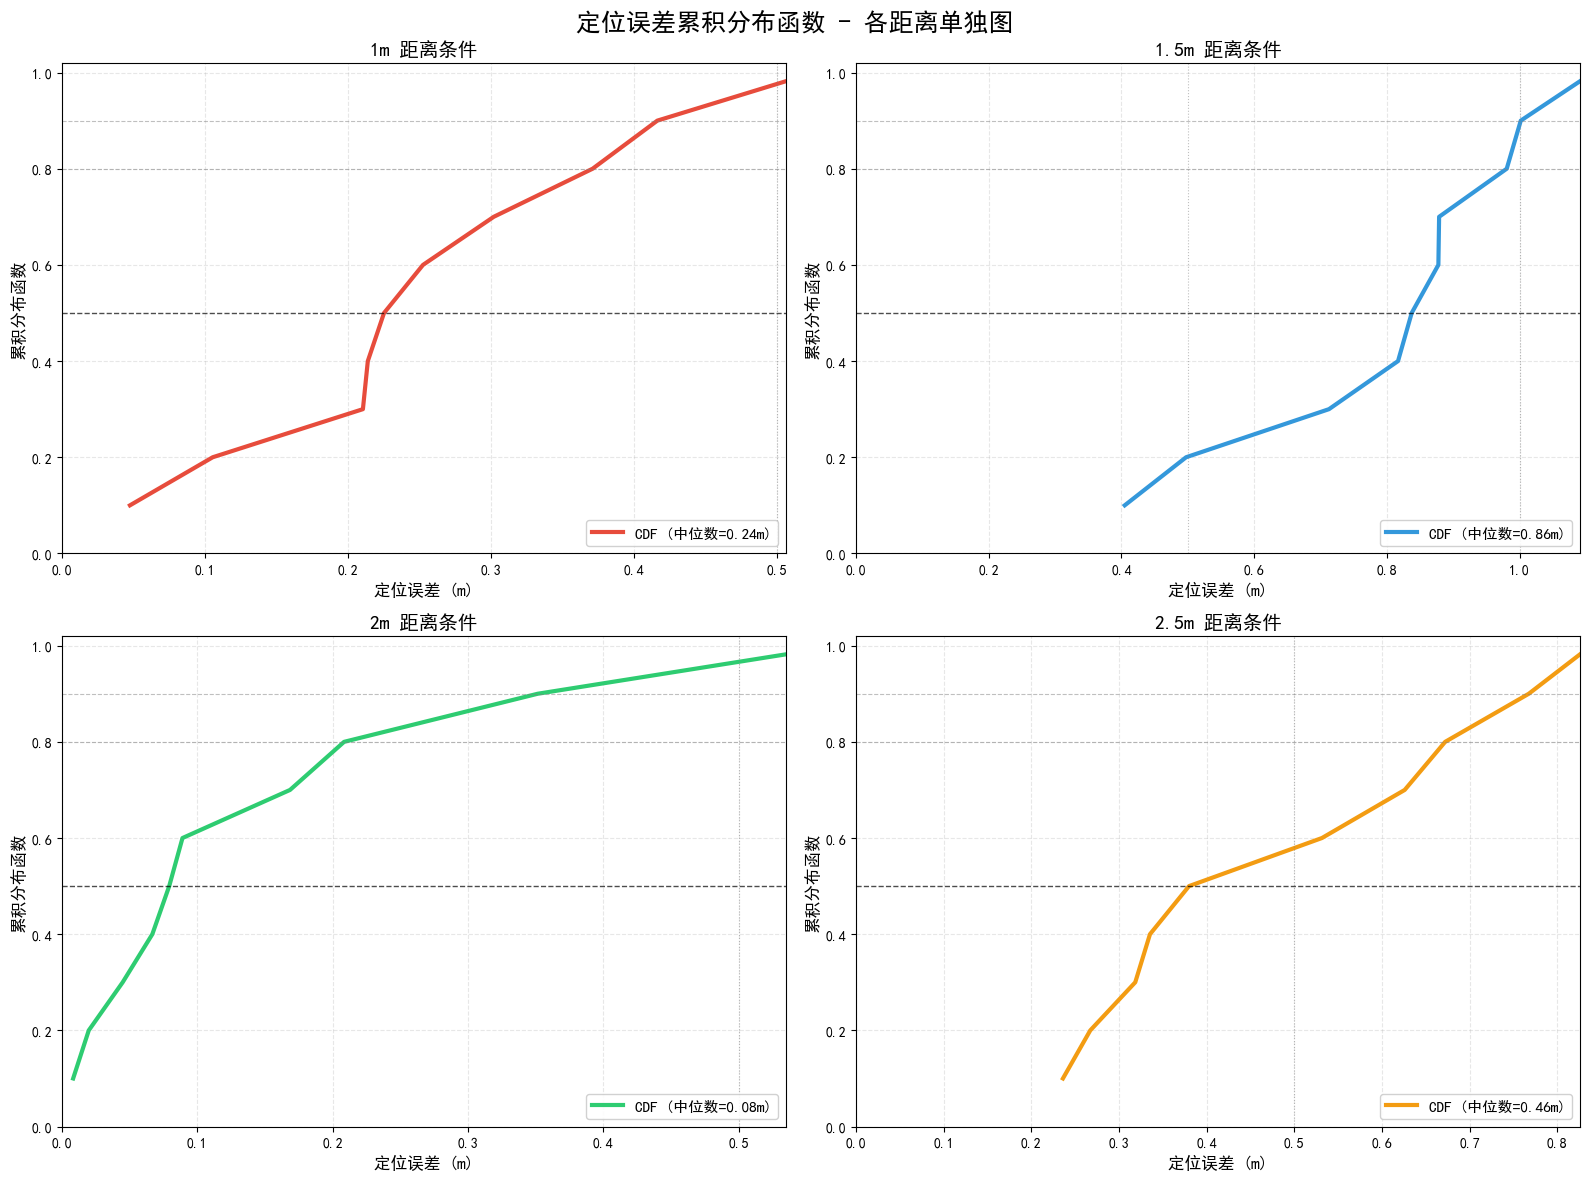

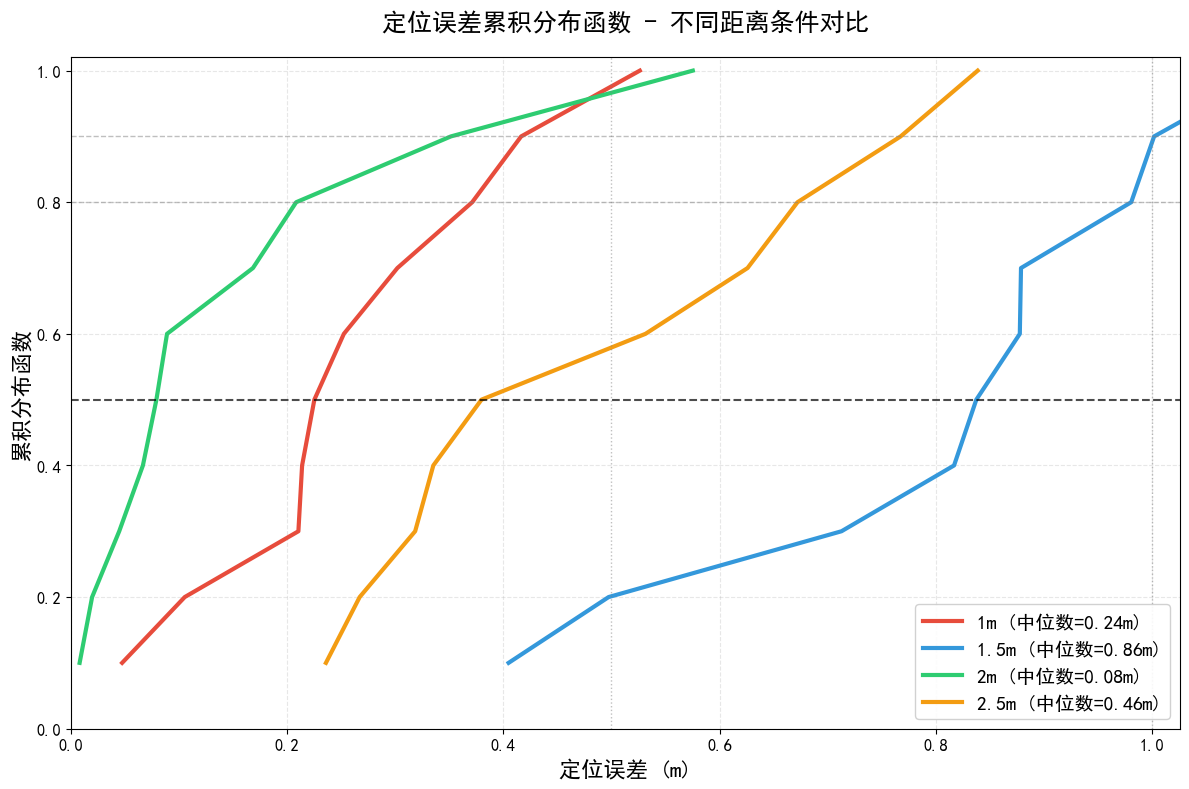

详细误差统计:
------------------------------------------------------------
1m:
  样本数量: 10
  均值: 0.267 m
  中位数: 0.239 m
  标准差: 0.136 m
  最小值: 0.048 m
  最大值: 0.526 m
  75%分位数: 0.354 m
  90%分位数: 0.428 m
  95%分位数: 0.477 m

1.5m:
  样本数量: 10
  均值: 0.812 m
  中位数: 0.858 m
  标准差: 0.209 m
  最小值: 0.405 m
  最大值: 1.111 m
  75%分位数: 0.955 m
  90%分位数: 1.013 m
  95%分位数: 1.062 m

2m:
  样本数量: 10
  均值: 0.161 m
  中位数: 0.084 m
  标准差: 0.170 m
  最小值: 0.008 m
  最大值: 0.575 m
  75%分位数: 0.198 m
  90%分位数: 0.374 m
  95%分位数: 0.475 m

2.5m:
  样本数量: 10
  均值: 0.497 m
  中位数: 0.456 m
  标准差: 0.208 m
  最小值: 0.236 m
  最大值: 0.839 m
  75%分位数: 0.661 m
  90%分位数: 0.775 m
  95%分位数: 0.807 m



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False



# 定义文件夹名称
folders = ['1m', '1.5m', '2m', '2.5m']

# 存储每个距离的数据
error_data = {}

# 读取每个文件夹中的CSV文件
for folder in folders:
    # 构建文件路径
    file_path = f"{folder}/{folder}几何反演结果.csv"
    
    # 检查文件是否存在
    if not os.path.exists(file_path):
        print(f"警告: 文件 {file_path} 不存在，跳过")
        continue
    
    try:
        # 读取CSV文件
        df = pd.read_csv(file_path)
        
        # 检查列名，找到包含distance_error的列
        distance_error_column = None
        for col in df.columns:
            if 'PositionError_m' in col.lower() or '距离' in col or 'error' in col.lower():
                distance_error_column = col
                break
        
        if distance_error_column is None:
            # 如果没有找到明确的列，尝试使用第11列（从0开始计数）
            print(f"{folder}: 未找到distance_error列，尝试使用第11列")
            if len(df.columns) >= 11:
                distance_error_column = df.columns[10]
            else:
                print(f"{folder}: CSV文件列数不足，跳过")
                continue
        
        print(f"{folder}: 使用列 '{distance_error_column}' 作为误差数据")
        
        # 提取误差数据并转换为数值类型
        errors = pd.to_numeric(df[distance_error_column], errors='coerce').values
        
        # 过滤掉NaN值
        valid_errors = errors[~np.isnan(errors)]
        
        if len(valid_errors) > 0:
            error_data[folder] = valid_errors
            print(f"{folder}: 读取了 {len(valid_errors)} 个有效误差数据")
        else:
            print(f"{folder}: 没有有效的误差数据")
            
    except Exception as e:
        print(f"读取 {folder} 文件夹时出错: {e}")

# 检查是否有数据
if not error_data:
    print("错误: 没有读取到任何有效数据")
    exit()

# 打印数据统计信息
print("\n数据统计信息:")
print("-" * 60)
for distance, errors in error_data.items():
    print(f"{distance}:")
    print(f"  样本数量: {len(errors)}")
    print(f"  均值: {errors.mean():.3f} m")
    print(f"  中位数: {np.median(errors):.3f} m")
    print(f"  最小值: {errors.min():.3f} m")
    print(f"  最大值: {errors.max():.3f} m")
    print(f"  标准差: {errors.std():.3f} m")
    print()

# 1. 创建四张单独的CDF图
fig_individual, axes = plt.subplots(2, 2, figsize=(16, 12))
fig_individual.suptitle('定位误差累积分布函数 - 各距离单独图', fontsize=18, fontweight='bold', y=0.98)

# 使用专业的颜色方案
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

# 将axes展平为一维数组以便遍历
axes_flat = axes.flat

for i, (distance, errors) in enumerate(error_data.items()):
    if i >= 4:  # 最多只显示4个子图
        break
    
    ax = axes_flat[i]
    
    # 计算CDF
    sorted_errors = np.sort(errors)
    cdf_values = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    
    # 绘制CDF曲线
    ax.plot(sorted_errors, cdf_values, 
            label=f'CDF (中位数={np.median(errors):.2f}m)', 
            color=colors[i], linewidth=3)
    
    # 设置图表样式
    ax.set_xlabel('定位误差 (m)', fontsize=12, fontweight='bold')
    ax.set_ylabel('累积分布函数', fontsize=12, fontweight='bold')
    ax.set_title(f'{distance} 距离条件', fontsize=14, fontweight='bold')
    
    # 设置网格和图例
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, loc='lower right', framealpha=0.9)
    
    # 设置坐标轴范围
    ax.set_xlim(0, min(8, np.percentile(errors, 98)))
    ax.set_ylim(0, 1.02)
    
    # 添加参考线
    ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, linewidth=1)
    ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    
    # 添加垂直参考线
    for ref_error in [0.5, 1.0, 2.0]:
        ax.axvline(x=ref_error, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

plt.tight_layout()
plt.show()

# 2. 创建整合四条线的CDF图
plt.figure(figsize=(12, 8))

# 使用相同的颜色方案
for i, (distance, errors) in enumerate(error_data.items()):
    # 计算CDF
    sorted_errors = np.sort(errors)
    cdf_values = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    
    # 绘制CDF曲线
    plt.plot(sorted_errors, cdf_values, 
             label=f'{distance} (中位数={np.median(errors):.2f}m)', 
             color=colors[i], linewidth=3)

# 设置图表样式
plt.xlabel('定位误差 (m)', fontsize=16, fontweight='bold')
plt.ylabel('累积分布函数', fontsize=16, fontweight='bold')
plt.title('定位误差累积分布函数 - 不同距离条件对比', fontsize=18, fontweight='bold', pad=20)

# 设置网格和图例
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=14, loc='lower right', framealpha=0.9)

# 设置坐标轴范围
all_valid_errors = np.concatenate(list(error_data.values()))
if len(all_valid_errors) > 0:
    plt.xlim(0, min(8, np.percentile(all_valid_errors, 98)))
    plt.ylim(0, 1.02)

# 添加参考线
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# 添加垂直参考线
for ref_error in [0.5, 1.0, 2.0]:
    plt.axvline(x=ref_error, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# 设置刻度
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# 3. 打印详细统计信息
print("详细误差统计:")
print("-" * 60)
for distance, errors in error_data.items():
    print(f"{distance}:")
    print(f"  样本数量: {len(errors)}")
    print(f"  均值: {errors.mean():.3f} m")
    print(f"  中位数: {np.median(errors):.3f} m")
    print(f"  标准差: {errors.std():.3f} m")
    
    print(f"  最小值: {errors.min():.3f} m")
    print(f"  最大值: {errors.max():.3f} m")
    print(f"  75%分位数: {np.percentile(errors, 75):.3f} m")
    print(f"  90%分位数: {np.percentile(errors, 90):.3f} m")
    print(f"  95%分位数: {np.percentile(errors, 95):.3f} m")
    print()